In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import glob
import os
import regex as re
import csv

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Manaus Population Correction

This notebook corrects the scale mismatch between model population and observed cases.

So far, the project has considered analyzing rural cases in the municipality of Manaus. Given that there is no data based only on this zone, we use a formula derived from the Trajetórias Project (https://www.nature.com/articles/s41597-023-01962-1):

$$\text{Incidence}(d,m,z,t_1,t_2)=\dfrac{\text{Cases}(d,m,z,t_1,t_2)}{\text{Pop}(m,z,(t_1+t_2)/2)\times 5\text{ years}}\times 10^5$$

The parameters are:
<ol>
  <p>$d$: disease (Chagas, CL, VL, Dengue, Falciparum, Vivax, Vivax+Falciparum)</p>
  <p>$m$: municipality</p>
  <p>$z$: zone (rural, urban or total)</p>
  <p>$[t_1,t_2]$: [2004,2008] or [2015, 2019]</p>
</ol>

<!-- ## Problem
- Model was using rural population (~8,558)
- Cases represent ALL of Manaus (~2M population)
- This caused inconsistency in model-data comparison

## Solution Options
1. **Option A**: Scale observed cases to rural level (multiply by 0.0037)
2. **Option B**: Use full municipal population in model (~2M)

We implement both approaches for comparison. -->

Below, we will approximate the population and number of cases in 2020, as the mean of our period [2017,2023], based on extrapolation of known data.

## Load Data

In [5]:
DATA_DIR = '../data'

climate_data = pd.read_csv(DATA_DIR + '/climate_api_data_2016_2024.csv')
cases_data = pd.read_csv(DATA_DIR + '/sivep_notification_data/treated_malaria_notification_data/cumulative_manaus_cases_2016_2023.csv')
pop_data = pd.read_csv(DATA_DIR + '/ibge_manaus_population_data_2016_2024.csv')
defor_data = pd.read_csv(DATA_DIR + '/deter_notification_data/treated_deter_deforestation_data_2016_2024.csv')
fires_data = pd.read_csv(DATA_DIR + '/inpe_fire_counts_data_2016_2024.csv')

climate_data['date'] = pd.to_datetime(climate_data['date'])
cases_data['date'] = pd.to_datetime(cases_data['date'])
pop_data['date'] = pd.to_datetime(pop_data['index'])
defor_data['date'] = pd.to_datetime(defor_data['date'])
fires_data['date'] = pd.to_datetime(fires_data['date'])

# Filter to 2017-2023
start_date = pd.to_datetime('2017-01-01')
end_date = pd.to_datetime('2023-12-31')
climate_data = climate_data[(climate_data['date'] >= start_date) & (climate_data['date'] <= end_date)].reset_index(drop=True)
cases_data = cases_data[(cases_data['date'] >= start_date) & (cases_data['date'] <= end_date)].reset_index(drop=True)
pop_data = pop_data[(pop_data['date'] >= start_date) & (pop_data['date'] <= end_date)].reset_index(drop=True)
defor_data = defor_data[(defor_data['date'] >= start_date) & (defor_data['date'] <= end_date)].reset_index(drop=True)
fires_data = fires_data[(fires_data['date'] >= start_date) & (fires_data['date'] <= end_date)].reset_index(drop=True)

print(f"Climate data: {len(climate_data)} days")
print(f"Cases data: {len(cases_data)} days")
print(f"Population data: {len(pop_data)} days")
print(f"Deforestation data: {len(defor_data)} days")
print(f"Fires data: {len(fires_data)} days")

Climate data: 2556 days
Cases data: 2556 days
Population data: 2556 days
Deforestation data: 2556 days
Fires data: 2556 days


In [6]:
with open("../data/TRAJETORIAS_DATASET_Epidemiological_dimension_indicators.csv", encoding="utf-8") as f:
    lines = f.readlines()

clean_lines = [line.replace('"', '') for line in lines]

trajetorias_epidem_df = pd.DataFrame([line.strip().split(",") for line in clean_lines])
trajetorias_epidem_df.columns = trajetorias_epidem_df.iloc[0]
trajetorias_epidem_df = trajetorias_epidem_df[1:].reset_index(drop=True)
trajetorias_epidem_df.columns = trajetorias_epidem_df.columns.str.replace('\ufeff', '')

with open("../data/TRAJETORIAS_DATASET_Population_indicators.csv", encoding="utf-8") as f:
    lines = f.readlines()

clean_lines = [line.replace('"', '') for line in lines]

trajetorias_pop_df = pd.DataFrame([line.strip().split(",") for line in clean_lines])
trajetorias_pop_df.columns = trajetorias_pop_df.iloc[0]
trajetorias_pop_df = trajetorias_pop_df[1:].reset_index(drop=True)
trajetorias_pop_df.columns = trajetorias_pop_df.columns.str.replace('\ufeff', '')

manaus_epidem_df = trajetorias_epidem_df[trajetorias_epidem_df['municipality']=='Manaus']
manaus_epidem_df = manaus_epidem_df.reset_index(drop=True)
manaus_vivax_df = manaus_epidem_df[manaus_epidem_df['disease']=='Vivax']
manaus_vivax_df = manaus_vivax_df.reset_index(drop=True)
manaus_vivax_df = manaus_vivax_df.drop(columns=['state_abbrev', 'state', 'municipality', 'geocode', 'disease'])

cols = ['cases', 'inc']

manaus_vivax_df[cols] = manaus_vivax_df[cols].apply(pd.to_numeric, errors='coerce')

manaus_pop_df = trajetorias_pop_df[trajetorias_pop_df['municipality']=='Manaus']
manaus_pop_df = manaus_pop_df.reset_index(drop=True)
manaus_rural_tot_pop_df = manaus_pop_df.drop(columns=['state_abbrev', 'state', 'municipality', 'geocode', 'prop_urb2000', 'prop_urb2010'])

cols = ['urb2000', 'rur2000', 'tot2000', 'prop_rur2000',
    'urb2010', 'rur2010', 'tot2010', 'prop_rur2010',
    'pop_estimated2006', 'pop_estimated2017',
    'urb2006e', 'rur2006e', 'urb2017e', 'rur2017e']

manaus_rural_tot_pop_df[cols] = manaus_rural_tot_pop_df[cols].apply(pd.to_numeric, errors='coerce')

In [7]:
manaus_vivax_df

,period,zone,cases,inc
0,2004-2008,rural,78745,184030.772087
1,2015-2019,rural,25859,60433.700367
2,2004-2008,urban,183519,2184.793966
3,2015-2019,urban,36387,433.187289
4,2004-2008,total,262264,3106.429047
5,2015-2019,total,62246,584.397051


In [8]:
manaus_rural_tot_pop_df

,urb2000,rur2000,tot2000,prop_rur2000,urb2010,rur2010,tot2010,prop_rur2010,pop_estimated2006,pop_estimated2017,urb2006e,rur2006e,urb2017e,rur2017e
0,1396768,9067,1405835,0.00645,1792881,9133,1802014,0.005068,1688524,2130264,1.679966e+06,8557.807926,2.119467e+06,10796.642597


In [9]:
print(f"Manaus 2000 rural population proportion: {manaus_rural_tot_pop_df['rur2000']/manaus_rural_tot_pop_df['tot2000']}")
print(f"Manaus 2010 rural population proportion: {manaus_rural_tot_pop_df['rur2010']/manaus_rural_tot_pop_df['tot2010']}")
print("--------------------------------------")
print(f"Manaus 2006 rural population proportion estimate: {manaus_rural_tot_pop_df['rur2006e']/manaus_rural_tot_pop_df['pop_estimated2006']}")
print(f"Manaus 2017 rural population proportion estimate: {manaus_rural_tot_pop_df['rur2017e']/manaus_rural_tot_pop_df['pop_estimated2017']}")

Manaus 2000 rural population proportion: 0    0.00645
dtype: float64
Manaus 2010 rural population proportion: 0    0.005068
dtype: float64
--------------------------------------
Manaus 2006 rural population proportion estimate: 0    0.005068
dtype: float64
Manaus 2017 rural population proportion estimate: 0    0.005068
dtype: float64


#### From this, we can see that the estimated rural population for 2006 and 2017 uses the exact same proportion of 2010, which may not be appropriate. With this in mind, we propose an estimation of the population ratio using the change from 2000 to 2010:

Instead of using a constant proportion from 2010, we can estimate proper proportions by:
1. Using the change from prop_rur2000 (0.645%) to prop_rur2010 (0.507%) over 10 years
2. Extrapolating this rate to 2006 and 2017

In [12]:
# Key values from Trajetorias
prop_rur_2000 = manaus_rural_tot_pop_df['prop_rur2000'].values[0]
prop_rur_2010 = manaus_rural_tot_pop_df['prop_rur2010'].values[0]

# Calculate annual change rate from 2000 to 2010
years_2000_2010 = 10
annual_change_rate = (prop_rur_2010 / prop_rur_2000) ** (1/years_2000_2010) - 1

print("=== PROPER RURAL PROPORTIONS ===")
print()
print(f"Annual change rate: {annual_change_rate*100:.2f}% per year")
print()
# Extrapolate to 2006
prop_rur_2006 = prop_rur_2000 * (1 + annual_change_rate) ** (2006 - 2000)
print(f"2006 (from 2000): {prop_rur_2006:.5f} ({prop_rur_2006*100:.2f}%)")

# Extrapolate to 2017
prop_rur_2017 = prop_rur_2010 * (1 + annual_change_rate) ** (2017 - 2010)
print(f"2017 (from 2010): {prop_rur_2017:.5f} ({prop_rur_2017*100:.2f}%)")
print()
print("These values are more accurate than the constant 0.5068% used in Trajetorias.")

=== PROPER RURAL PROPORTIONS ===

Annual change rate: -2.38% per year

2006 (from 2000): 0.00558 (0.56%)
2017 (from 2010): 0.00428 (0.43%)

These values are more accurate than the constant 0.5068% used in Trajetorias.


In [13]:
# Get total populations from Trajetorias
total_pop_2006 = manaus_rural_tot_pop_df['pop_estimated2006'].values[0]
total_pop_2017 = manaus_rural_tot_pop_df['pop_estimated2017'].values[0]

# Calculate rural populations using new proportions
rural_pop_2006_new = total_pop_2006 * prop_rur_2006
urban_pop_2006_new = total_pop_2006 - rural_pop_2006_new

rural_pop_2017_new = total_pop_2017 * prop_rur_2017
urban_pop_2017_new = total_pop_2017 - rural_pop_2017_new

print("=== ESTIMATED POPULATIONS USING NEW PROPORTIONS ===")
print()
print("2006:")
print(f"  Total: {total_pop_2006:,}")
print(f"  Rural: {rural_pop_2006_new:,.0f} ({prop_rur_2006*100:.2f}%)")
print(f"  Urban: {urban_pop_2006_new:,.0f} ({urban_pop_2006_new/total_pop_2006*100:.2f}%)")
print()
print("2017:")
print(f"  Total: {total_pop_2017:,}")
print(f"  Rural: {rural_pop_2017_new:,.0f} ({prop_rur_2017*100:.2f}%)")
print(f"  Urban: {urban_pop_2017_new:,.0f} ({urban_pop_2017_new/total_pop_2017*100:.2f}%)")

=== ESTIMATED POPULATIONS USING NEW PROPORTIONS ===

2006:
  Total: 1,688,524
  Rural: 9,424 (0.56%)
  Urban: 1,679,100 (99.44%)

2017:
  Total: 2,130,264
  Rural: 9,120 (0.43%)
  Urban: 2,121,144 (99.57%)


#### The following tests show that the rural and urban incidence was incorrectly calculated for 2015-2019, using the populations from 2006 instead of 2017.

In [15]:
test_rural_inc_2004_2008 = 78745/(8558*5)*10**5
test_rural_inc_2004_2008

184026.641738724

In [16]:
test_rural_inc_2015_2019 = 25859/(10797*5)*10**5
test_rural_inc_2015_2019

47900.34268778364

In [17]:
test_urban_inc_2004_2008 = 183519/(1679966*5)*10**5
test_urban_inc_2004_2008

2184.7942160734206

In [18]:
test_urban_inc_2015_2019 = 36387/(2119467*5)*10**5
test_urban_inc_2015_2019

343.35991077001904

In [19]:
test_total_inc_2004_2008 = 262264/(1688524*5)*10**5
test_total_inc_2004_2008

3106.42904690724

In [20]:
test_total_inc_2015_2019 = 62246/(2130264*5)*10**5
test_total_inc_2015_2019

584.3970512574967

In [21]:
test_broken_rural_inc_2015_2019 = 25859/(8558*5)*10**5
test_broken_rural_inc_2015_2019

60432.344005608786

In [22]:
test_broken_urban_inc_2015_2019 = 36387/(1679966*5)*10**5
test_broken_urban_inc_2015_2019

433.18733831518017

#### Below, we will recalculate the incidences

In [24]:
# Extracting the correct midpoint populations 
pop_rural_2006 = rural_pop_2006_new #manaus_rural_tot_pop_df.loc[0, 'rur2017e']
pop_urban_2006 = urban_pop_2006_new

pop_rural_2017 = rural_pop_2017_new #manaus_rural_tot_pop_df.loc[0, 'rur2017e']
pop_urban_2017 = urban_pop_2017_new #manaus_rural_tot_pop_df.loc[0, 'urb2017e']

# Incidence calculation
def compute_incidence(cases, population, years=5):
    return (cases / (population * years)) * 1e5

# Applying correction to 2004–2008
mask_2004_2008 = manaus_vivax_df['period'] == '2004-2008'

# Rural
mask_rural = manaus_vivax_df['zone'] == 'rural'
cases_rural = manaus_vivax_df.loc[mask_2004_2008 & mask_rural, 'cases']

manaus_vivax_df.loc[mask_2004_2008 & mask_rural, 'inc'] = (
    compute_incidence(cases_rural, pop_rural_2006)
)

# Urban
mask_urban = manaus_vivax_df['zone'] == 'urban'
cases_urban = manaus_vivax_df.loc[mask_2004_2008 & mask_urban, 'cases']

manaus_vivax_df.loc[mask_2004_2008 & mask_urban, 'inc'] = (
    compute_incidence(cases_urban, pop_urban_2006)
)

###################################

# Applying correction to 2015–2019
mask_2015_2019 = manaus_vivax_df['period'] == '2015-2019'

# Rural
mask_rural = manaus_vivax_df['zone'] == 'rural'
cases_rural = manaus_vivax_df.loc[mask_2015_2019 & mask_rural, 'cases']

manaus_vivax_df.loc[mask_2015_2019 & mask_rural, 'inc'] = (
    compute_incidence(cases_rural, pop_rural_2017)
)

# Urban
mask_urban = manaus_vivax_df['zone'] == 'urban'
cases_urban = manaus_vivax_df.loc[mask_2015_2019 & mask_urban, 'cases']

manaus_vivax_df.loc[mask_2015_2019 & mask_urban, 'inc'] = (
    compute_incidence(cases_urban, pop_urban_2017)
)

##############################################
manaus_vivax_df

,period,zone,cases,inc
0,2004-2008,rural,78745,167117.088662
1,2015-2019,rural,25859,56705.446433
2,2004-2008,urban,183519,2185.920940
3,2015-2019,urban,36387,343.088522
4,2004-2008,total,262264,3106.429047
5,2015-2019,total,62246,584.397051


In [25]:
# Use the CORRECTED incidence values (recalculated with corrected populations)
# These override the wrong values from Trajetorias

# Corrected populations from our new analysis
pop_rural_2006_corrected = rural_pop_2006_new
pop_rural_2017_corrected = rural_pop_2017_new

# Corrected incidences
rural_inc_04_08_corrected = 78745 / (pop_rural_2006_corrected * 5) * 100000
rural_inc_15_19_corrected = 25859 / (pop_rural_2017_corrected * 5) * 100000

urban_inc_04_08_corrected = 183519 / (pop_urban_2006 * 5) * 100000
urban_inc_15_19_corrected = 36387 / (pop_urban_2017 * 5) * 100000

print("=== CORRECTED INCIDENCE VALUES ===")
print(f"Rural 2004-2008: {rural_inc_04_08_corrected:.2f}")
print(f"Rural 2015-2019: {rural_inc_15_19_corrected:.2f}")
print(f"Urban 2004-2008: {urban_inc_04_08_corrected:.2f}")
print(f"Urban 2015-2019: {urban_inc_15_19_corrected:.2f}")

=== CORRECTED INCIDENCE VALUES ===
Rural 2004-2008: 167117.09
Rural 2015-2019: 56705.45
Urban 2004-2008: 2185.92
Urban 2015-2019: 343.09


In [26]:
# Calculate rate using CORRECTED incidence values
r_corrected = (rural_inc_15_19_corrected / rural_inc_04_08_corrected) ** (1/11) - 1

print(f"Annual change rate (CORRECTED): {r_corrected*100:.2f}% per year")
print(f"Old rate (WRONG): -9.63% per year")

# Extrapolate using corrected rate
rural_inc_20_corrected = rural_inc_15_19_corrected * (1 + r_corrected) ** (2020 - 2017)
rural_inc_21_corrected = rural_inc_15_19_corrected * (1 + r_corrected) ** (2021 - 2017)
rural_inc_22_corrected = rural_inc_15_19_corrected * (1 + r_corrected) ** (2022 - 2017)
rural_inc_23_corrected = rural_inc_15_19_corrected * (1 + r_corrected) ** (2023 - 2017)

print("\nCorrected incidence for 2020-2023:")
print(f"2020: {rural_inc_20_corrected:.2f}")
print(f"2021: {rural_inc_21_corrected:.2f}")
print(f"2022: {rural_inc_22_corrected:.2f}")
print(f"2023: {rural_inc_23_corrected:.2f}")

Annual change rate (CORRECTED): -9.36% per year
Old rate (WRONG): -9.63% per year

Corrected incidence for 2020-2023:
2020: 42228.69
2021: 38276.77
2022: 34694.68
2023: 31447.82


In [27]:
# Calculate exact ratios from TRAJETORIAS data
print("=== Calculated from TRAJETORIAS Dataset ===\n")

# Filter data for each period and zone
rural_04_08 = manaus_vivax_df[(manaus_vivax_df['period']=='2004-2008') & (manaus_vivax_df['zone']=='rural')]
total_04_08 = manaus_vivax_df[(manaus_vivax_df['period']=='2004-2008') & (manaus_vivax_df['zone']=='total')]
rural_15_19 = manaus_vivax_df[(manaus_vivax_df['period']=='2015-2019') & (manaus_vivax_df['zone']=='rural')]
total_15_19 = manaus_vivax_df[(manaus_vivax_df['period']=='2015-2019') & (manaus_vivax_df['zone']=='total')]

rural_cases_04_08 = rural_04_08['cases'].values[0]
total_cases_04_08 = total_04_08['cases'].values[0]
rural_cases_15_19 = rural_15_19['cases'].values[0]
total_cases_15_19 = total_15_19['cases'].values[0]

rural_inc_04_08 = rural_04_08['inc'].values[0]
total_inc_04_08 = total_04_08['inc'].values[0]
rural_inc_15_19 = rural_15_19['inc'].values[0]
total_inc_15_19 = total_15_19['inc'].values[0]

# Case ratios
case_ratio_04_08 = rural_cases_04_08 / total_cases_04_08
case_ratio_15_19 = rural_cases_15_19 / total_cases_15_19

print(f"Case Ratios (Rural/Total):")
print(f"  2004-2008: {case_ratio_04_08*100:.2f}% ({rural_cases_04_08:,}/{total_cases_04_08:,})")
print(f"  2015-2019: {case_ratio_15_19*100:.2f}% ({rural_cases_15_19:,}/{total_cases_15_19:,})")

=== Calculated from TRAJETORIAS Dataset ===

Case Ratios (Rural/Total):
  2004-2008: 30.03% (78,745/262,264)
  2015-2019: 41.54% (25,859/62,246)


In [28]:
# Population from incidence formula: Pop = (Cases × 100000) / (Inc × 5 years)
pop_rural_04_08 = rural_cases_04_08 * 100000 / (rural_inc_04_08 * 5)
pop_total_04_08 = total_cases_04_08 * 100000 / (total_inc_04_08 * 5)
pop_ratio_04_08 = pop_rural_04_08 / pop_total_04_08

pop_rural_15_19 = rural_cases_15_19 * 100000 / (rural_inc_15_19 * 5)
pop_total_15_19 = total_cases_15_19 * 100000 / (total_inc_15_19 * 5)
pop_ratio_15_19 = pop_rural_15_19 / pop_total_15_19

print(f"\nPopulation Ratios (Rural/Total) from Incidence:")
print(f"  2004-2008: {pop_ratio_04_08*100:.2f}% (rural pop: {pop_rural_04_08:,.0f})")
print(f"  2015-2019: {pop_ratio_15_19*100:.2f}% (rural pop: {pop_rural_15_19:,.0f})")


Population Ratios (Rural/Total) from Incidence:
  2004-2008: 0.56% (rural pop: 9,424)
  2015-2019: 0.43% (rural pop: 9,120)


Now, we would like to see the behavior of the transmission and population in the period of our study, which is 2017 to 2023.

Given that the years of 2017 to 2019 are already included in the estimates above, we should only consider 2020 to 2023.

Let's assume the annual growth rate of the disease is given by

$$r=\left(\dfrac{\text{Inc}_{[2015,2019]}}{\text{Inc}_{[2004,2008]}}\right)^{1/11}-1$$

Then $\text{Inc}_y$, for each year $y$, is given by

$$\text{Inc}_y=\text{Inc}_{[2015,2019]}\times(1+r)^{y-2017} $$

In [32]:
rural_inc_15_19

np.float64(56705.446433216865)

In [33]:
rural_inc_15_19/rural_inc_04_08

np.float64(0.3393156671609115)

In [34]:
r = (rural_inc_15_19/rural_inc_04_08)**(1/11) -1
r

np.float64(-0.09358386357602777)

In [35]:
rural_inc_20 = rural_inc_15_19*(1+r)**(2020-2017)
rural_inc_21 = rural_inc_15_19*(1+r)**(2021-2017)
rural_inc_22 = rural_inc_15_19*(1+r)**(2022-2017)
rural_inc_23 = rural_inc_15_19*(1+r)**(2023-2017)

print(f'The rural incidence in the years of 2020 to 2023 are estimated to be, respectively: \n{rural_inc_20}, {rural_inc_21}, {rural_inc_22}, {rural_inc_23}')

The rural incidence in the years of 2020 to 2023 are estimated to be, respectively: 
42228.694868450184, 38276.770448887444, 34694.68238506783, 31447.819961930025


In [36]:
pop_data_clean = pop_data.copy()
pop_data_clean.drop(columns=['index', 'ADJUSTED_RURAL_POP'])
pop_data_clean = pop_data_clean[['date', 'ADJUSTED_POPULATION']]
pop_data_clean

,date,ADJUSTED_POPULATION
0,2017-01-01,1.954657e+06
1,2017-01-02,1.954717e+06
2,2017-01-03,1.954776e+06
3,2017-01-04,1.954836e+06
4,2017-01-05,1.954896e+06
...,...,...
2551,2023-12-27,2.222621e+06
2552,2023-12-28,2.222840e+06
2553,2023-12-29,2.223059e+06
2554,2023-12-30,2.223279e+06


In [37]:
# ============================================
# EXTRAPOLATE RURAL PROPORTION FOR 2017-2023
# ============================================

# Extract rural proportion from estimated Trajetorias data
# From manaus_rural_tot_pop_df:
# prop_rur2000 = 0.00645 (year 2000)
# prop_rur2010 = 0.005068 (year 2010)
# But we need proportions for 2006 (midpoint 2004-2008) and 2017 (midpoint 2015-2019)

# From the dataset, we have:
# rur2006e = 8,557.8 (estimated rural population in 2006)
# pop_estimated2006 = 1,688,524 (total population in 2006)
# rur2017e = 10,796.64 (estimated rural population in 2017)
# pop_estimated2017 = 2,130,264 (total population in 2017)

rural_pop_2006 = pop_rural_2006 #manaus_rural_tot_pop_df['rur2006e'].values[0]
total_pop_2006 = manaus_rural_tot_pop_df['pop_estimated2006'].values[0]
prop_rural_2006 = rural_pop_2006 / total_pop_2006

rural_pop_2017 = pop_rural_2017 #manaus_rural_tot_pop_df['rur2017e'].values[0]
total_pop_2017 = manaus_rural_tot_pop_df['pop_estimated2017'].values[0]
prop_rural_2017 = rural_pop_2017 / total_pop_2017

print(f"Rural proportion in 2006: {prop_rural_2006:.6f} ({prop_rural_2006*100:.4f}%)")
print(f"Rural proportion in 2017: {prop_rural_2017:.6f} ({prop_rural_2017*100:.4f}%)")

# Calculate annual change rate for rural proportion (using exponential decay)
# Since rural proportion tends to decrease, exponential model: p(y) = p_2017 * (1 + r_p)^(y-2017)
# Where r_p = (p_2017/p_2006)^(1/11) - 1

r_p = (prop_rural_2017 / prop_rural_2006) ** (1/11) - 1
print(f"\nAnnual change rate for rural proportion: {r_p:.6f} ({r_p*100:.4f}% per year)")

# Extrapolate rural proportion for 2020-2023
years = [2020, 2021, 2022, 2023]
prop_rural_extrap = {}

for y in years:
    prop_rural_extrap[y] = prop_rural_2017 * (1 + r_p) ** (y - 2017)
    print(f"Projected rural proportion for {y}: {prop_rural_extrap[y]:.6f} ({prop_rural_extrap[y]*100:.4f}%)")

Rural proportion in 2006: 0.005581 (0.5581%)
Rural proportion in 2017: 0.004281 (0.4281%)

Annual change rate for rural proportion: -0.023814 (-2.3814% per year)
Projected rural proportion for 2020: 0.003983 (0.3983%)
Projected rural proportion for 2021: 0.003888 (0.3888%)
Projected rural proportion for 2022: 0.003795 (0.3795%)
Projected rural proportion for 2023: 0.003705 (0.3705%)


In [38]:
# ============================================
# CALCULATE DAILY RURAL POPULATION
# ============================================

# Create a function to get rural proportion for any date
def get_rural_proportion(date, prop_2006, prop_2017, year_2006=2006, year_2017=2017):
    """
    Calculate rural proportion for a given date using exponential interpolation/extrapolation
    """
    # Convert date to decimal year
    year = date.year
    day_of_year = date.timetuple().tm_yday
    days_in_year = 366 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 365
    year_frac = year + (day_of_year - 0.5) / days_in_year
    
    if year_frac <= year_2017:
        # Interpolate between 2006 and 2017
        t = (year_frac - year_2006) / (year_2017 - year_2006)
        # Linear interpolation on log scale for exponential trend
        prop = prop_2006 * (prop_2017 / prop_2006) ** t
    else:
        # Extrapolate beyond 2017
        r_p = (prop_2017 / prop_2006) ** (1/(year_2017 - year_2006)) - 1
        prop = prop_2017 * (1 + r_p) ** (year_frac - year_2017)
    
    return prop

# Calculate rural proportion for each day in pop_data
pop_data_clean = pop_data[['date', 'ADJUSTED_POPULATION']].copy()
pop_data_clean['rural_proportion'] = pop_data_clean['date'].apply(
    lambda d: get_rural_proportion(d, prop_rural_2006, prop_rural_2017)
)
pop_data_clean['rural_population'] = pop_data_clean['ADJUSTED_POPULATION'] * pop_data_clean['rural_proportion']

print(f"\nRural population statistics (2017-2023):")
print(f"  Min: {pop_data_clean['rural_population'].min():,.0f}")
print(f"  Max: {pop_data_clean['rural_population'].max():,.0f}")
print(f"  Mean: {pop_data_clean['rural_population'].mean():,.0f}")

pop_data_clean


Rural population statistics (2017-2023):
  Min: 7,832
  Max: 8,368
  Mean: 8,054


,date,ADJUSTED_POPULATION,rural_proportion,rural_population
0,2017-01-01,1.954657e+06,0.004281,8368.348151
1,2017-01-02,1.954717e+06,0.004281,8368.051348
2,2017-01-03,1.954776e+06,0.004281,8367.754547
3,2017-01-04,1.954836e+06,0.004280,8367.457750
4,2017-01-05,1.954896e+06,0.004280,8367.160955
...,...,...,...,...
2551,2023-12-27,2.222621e+06,0.003618,8040.928307
2552,2023-12-28,2.222840e+06,0.003618,8041.190380
2553,2023-12-29,2.223059e+06,0.003617,8041.452382
2554,2023-12-30,2.223279e+06,0.003617,8041.714315


In [39]:
# ============================================
# CALCULATE DAILY INCIDENCE RATES
# ============================================

# We have:
# rural_inc_15_19 = 60,433.7 cases per 100,000 person-years for 2015-2019
# This applies to 2015, 2016, 2017, 2018, 2019

# For 2020-2023, we already extrapolated:
# rural_inc_20, rural_inc_21, rural_inc_22, rural_inc_23

def get_annual_incidence(date, inc_2017, inc_2020, inc_2021, inc_2022, inc_2023):
    """
    Get annual incidence rate (per 100,000 person-years) for a given date
    """
    year = date.year
    
    if year <= 2019:
        return inc_2017  # Use 2015-2019 average for 2017-2019
    elif year == 2020:
        return inc_2020
    elif year == 2021:
        return inc_2021
    elif year == 2022:
        return inc_2022
    elif year == 2023:
        return inc_2023
    else:
        # For any other year, continue extrapolation
        r = (rural_inc_15_19 / rural_inc_04_08) ** (1/11) - 1
        return rural_inc_15_19 * (1 + r) ** (year - 2017)

# Add incidence to dataframe
pop_data_clean['annual_incidence_per_100k'] = pop_data_clean['date'].apply(
    lambda d: get_annual_incidence(d, rural_inc_15_19, rural_inc_20, rural_inc_21, rural_inc_22, rural_inc_23)
)

# Convert to daily rate (per person per day)
# Daily rate = (annual_incidence_per_100k / 100,000) / 365.25
pop_data_clean['daily_incidence_rate'] = (pop_data_clean['annual_incidence_per_100k'] / 100000) / 365.25

print(f"\nIncidence rates:")
print(f"  2017-2019: {rural_inc_15_19:.2f} per 100,000 person-years")
print(f"  2020: {rural_inc_20:.2f} per 100,000 person-years")
print(f"  2021: {rural_inc_21:.2f} per 100,000 person-years")
print(f"  2022: {rural_inc_22:.2f} per 100,000 person-years")
print(f"  2023: {rural_inc_23:.2f} per 100,000 person-years")

pop_data_clean


Incidence rates:
  2017-2019: 56705.45 per 100,000 person-years
  2020: 42228.69 per 100,000 person-years
  2021: 38276.77 per 100,000 person-years
  2022: 34694.68 per 100,000 person-years
  2023: 31447.82 per 100,000 person-years


,date,ADJUSTED_POPULATION,rural_proportion,rural_population,annual_incidence_per_100k,daily_incidence_rate
0,2017-01-01,1.954657e+06,0.004281,8368.348151,56705.446433,0.001553
1,2017-01-02,1.954717e+06,0.004281,8368.051348,56705.446433,0.001553
2,2017-01-03,1.954776e+06,0.004281,8367.754547,56705.446433,0.001553
3,2017-01-04,1.954836e+06,0.004280,8367.457750,56705.446433,0.001553
4,2017-01-05,1.954896e+06,0.004280,8367.160955,56705.446433,0.001553
...,...,...,...,...,...,...
2551,2023-12-27,2.222621e+06,0.003618,8040.928307,31447.819962,0.000861
2552,2023-12-28,2.222840e+06,0.003618,8041.190380,31447.819962,0.000861
2553,2023-12-29,2.223059e+06,0.003617,8041.452382,31447.819962,0.000861
2554,2023-12-30,2.223279e+06,0.003617,8041.714315,31447.819962,0.000861


In [40]:
# ============================================
# CALCULATE EXPECTED DAILY CASES
# ============================================

# Expected cases = daily_incidence_rate * rural_population
pop_data_clean['expected_daily_cases'] = pop_data_clean['daily_incidence_rate'] * pop_data_clean['rural_population']

print(f"\nExpected daily cases statistics (2017-2023):")
print(f"  Min: {pop_data_clean['expected_daily_cases'].min():.2f}")
print(f"  Max: {pop_data_clean['expected_daily_cases'].max():.2f}")
print(f"  Mean: {pop_data_clean['expected_daily_cases'].mean():.2f}")
print(f"  Total (sum): {pop_data_clean['expected_daily_cases'].sum():.0f}")

pop_data_clean


Expected daily cases statistics (2017-2023):
  Min: 6.84
  Max: 12.99
  Mean: 10.01
  Total (sum): 25596


,date,ADJUSTED_POPULATION,rural_proportion,rural_population,annual_incidence_per_100k,daily_incidence_rate,expected_daily_cases
0,2017-01-01,1.954657e+06,0.004281,8368.348151,56705.446433,0.001553,12.991948
1,2017-01-02,1.954717e+06,0.004281,8368.051348,56705.446433,0.001553,12.991488
2,2017-01-03,1.954776e+06,0.004281,8367.754547,56705.446433,0.001553,12.991027
3,2017-01-04,1.954836e+06,0.004280,8367.457750,56705.446433,0.001553,12.990566
4,2017-01-05,1.954896e+06,0.004280,8367.160955,56705.446433,0.001553,12.990105
...,...,...,...,...,...,...,...
2551,2023-12-27,2.222621e+06,0.003618,8040.928307,31447.819962,0.000861,6.923194
2552,2023-12-28,2.222840e+06,0.003618,8041.190380,31447.819962,0.000861,6.923420
2553,2023-12-29,2.223059e+06,0.003617,8041.452382,31447.819962,0.000861,6.923645
2554,2023-12-30,2.223279e+06,0.003617,8041.714315,31447.819962,0.000861,6.923871


In [41]:
# ============================================
# AGGREGATE RESULTS BY YEAR
# ============================================

# Add year column
pop_data_clean['year'] = pop_data_clean['date'].dt.year

# Aggregate by year
yearly_summary = pop_data_clean.groupby('year').agg({
    'rural_population': 'mean',
    'annual_incidence_per_100k': 'first',
    'expected_daily_cases': 'sum'
}).round(2)

yearly_summary['expected_yearly_cases'] = yearly_summary['expected_daily_cases']
yearly_summary['expected_yearly_cases_per_100k'] = (yearly_summary['expected_yearly_cases'] / yearly_summary['rural_population']) * 100000

print("\n=== YEARLY SUMMARY ===\n")
print(yearly_summary[['rural_population', 'annual_incidence_per_100k', 'expected_yearly_cases', 'expected_yearly_cases_per_100k']])

# Total for 2017-2023
total_cases_2017_2023 = pop_data_clean['expected_daily_cases'].sum()
total_rural_pop_mean = pop_data_clean['rural_population'].mean()

print(f"\n=== TOTAL 2017-2023 ===\n")
print(f"Total expected rural cases: {total_cases_2017_2023:.0f}")
print(f"Mean rural population: {total_rural_pop_mean:.0f}")
print(f"Overall incidence rate: {(total_cases_2017_2023 / total_rural_pop_mean) * 100000:.2f} per 100,000 person-years")


=== YEARLY SUMMARY ===

      rural_population  annual_incidence_per_100k  expected_yearly_cases  \
year                                                                       
2017           8314.39                   56705.45                4711.49   
2018           8206.44                   56705.45                4650.31   
2019           8098.92                   56705.45                4589.38   
2020           7991.86                   42228.69                3381.79   
2021           7885.31                   38276.77                3016.18   
2022           7887.70                   34694.68                2734.74   
2023           7992.77                   31447.82                2511.83   

      expected_yearly_cases_per_100k  
year                                  
2017                    56666.694730  
2018                    56666.593553  
2019                    56666.567888  
2020                    42315.430951  
2021                    38250.620458  
2022             

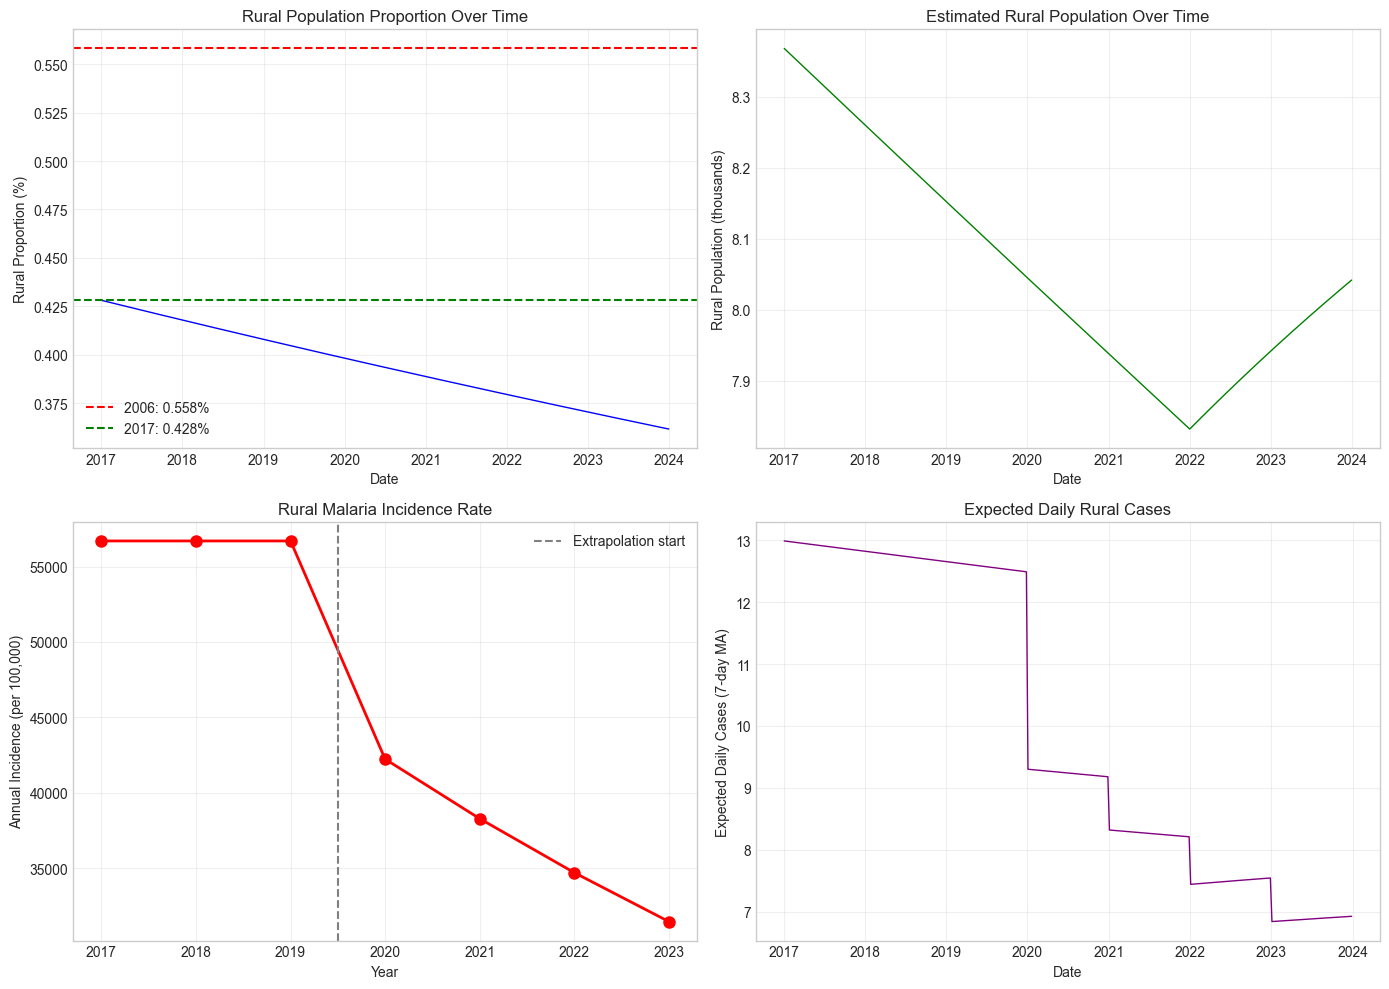

In [42]:
# ============================================
# VISUALIZATION
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Rural proportion over time
axes[0,0].plot(pop_data_clean['date'], pop_data_clean['rural_proportion'] * 100, 'b-', linewidth=1)
axes[0,0].axhline(y=prop_rural_2006*100, color='r', linestyle='--', label=f'2006: {prop_rural_2006*100:.3f}%')
axes[0,0].axhline(y=prop_rural_2017*100, color='g', linestyle='--', label=f'2017: {prop_rural_2017*100:.3f}%')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Rural Proportion (%)')
axes[0,0].set_title('Rural Population Proportion Over Time')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Rural population
axes[0,1].plot(pop_data_clean['date'], pop_data_clean['rural_population'] / 1000, 'g-', linewidth=1)
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Rural Population (thousands)')
axes[0,1].set_title('Estimated Rural Population Over Time')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Annual incidence rate
years_for_plot = [2017, 2018, 2019, 2020, 2021, 2022, 2023]
incidence_for_plot = [rural_inc_15_19, rural_inc_15_19, rural_inc_15_19, 
                      rural_inc_20, rural_inc_21, rural_inc_22, rural_inc_23]
axes[1,0].plot(years_for_plot, incidence_for_plot, 'r-o', linewidth=2, markersize=8)
axes[1,0].axvline(x=2019.5, color='gray', linestyle='--', label='Extrapolation start')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Annual Incidence (per 100,000)')
axes[1,0].set_title('Rural Malaria Incidence Rate')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Expected daily cases (7-day moving average)
pop_data_clean['cases_7day_ma'] = pop_data_clean['expected_daily_cases'].rolling(window=7, center=True).mean()
axes[1,1].plot(pop_data_clean['date'], pop_data_clean['cases_7day_ma'], 'purple', linewidth=1)
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Expected Daily Cases (7-day MA)')
axes[1,1].set_title('Expected Daily Rural Cases')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Estimating the population of Manaus between 2000, 2010, 2022 and 2025 by linear interpolation

In [44]:
pop_manaus_2000 = 1403796 ### https://biblioteca.ibge.gov.br/index.php/biblioteca-catalogo?view=detalhes&id=7308 (Tabelas Excel > AM > UF > Tabela 15)
pop_manaus_2010 = 1802014 ### https://www.ibge.gov.br/estatisticas/sociais/populacao/9662-censo-demografico-2010.html?=&t=resultados (Amazonas > Tabela 2.1.3)
pop_manaus_2022 = 2063689 ### https://cidades.ibge.gov.br/brasil/am/manaus/panorama, https://www.ibge.gov.br/cidades-e-estados/am/manaus.html
pop_manaus_2025 = 2303732 ### ESTIMATED, https://cidades.ibge.gov.br/brasil/am/manaus/panorama, https://www.ibge.gov.br/cidades-e-estados/am/manaus.html


ibge_pop_data = {
    'YEAR': [2000, 2010, 2022, 2025],
    'POPULATION': [pop_manaus_2000, pop_manaus_2010, pop_manaus_2022, pop_manaus_2025]
}

ibge_pop_data_df = pd.DataFrame(ibge_pop_data)

ibge_pop_data_df.set_index('YEAR', inplace=True)

ibge_pop_data_df_interpolated = ibge_pop_data_df.reindex(range(2000, 2026))  # Reindex to include all years from 2000 to 2025
ibge_pop_data_df_interpolated['POPULATION'] = ibge_pop_data_df_interpolated['POPULATION'].interpolate(method='linear')

ibge_pop_data_df_interpolated.reset_index(inplace=True)

ibge_pop_data_df_interpolated['POPULATION'] = ibge_pop_data_df_interpolated['POPULATION'].astype(int)

ibge_pop_data_df_interpolated

,YEAR,POPULATION
0,2000,1403796
1,2001,1443617
2,2002,1483439
3,2003,1523261
4,2004,1563083
5,2005,1602905
6,2006,1642726
7,2007,1682548
8,2008,1722370
9,2009,1762192


In [45]:
# Extract known rural proportion anchor points (already calculated)
rural_pop_2006 = manaus_rural_tot_pop_df['rur2006e'].values[0]
total_pop_2006 = manaus_rural_tot_pop_df['pop_estimated2006'].values[0]
prop_rural_2006 = rural_pop_2006 / total_pop_2006

rural_pop_2017 = manaus_rural_tot_pop_df['rur2017e'].values[0]
total_pop_2017 = manaus_rural_tot_pop_df['pop_estimated2017'].values[0]
prop_rural_2017 = rural_pop_2017 / total_pop_2017

# Function to estimate rural proportion for any year using exponential method
def estimate_rural_proportion(year, prop_2006=prop_rural_2006, prop_2017=prop_rural_2017, 
                               year_2006=2006, year_2017=2017):
    """
    Estimate rural proportion using exponential interpolation/extrapolation
    """
    if year <= year_2017:
        # Interpolate between 2006 and 2017
        t = (year - year_2006) / (year_2017 - year_2006)
        prop = prop_2006 * (prop_2017 / prop_2006) ** t
    else:
        # Extrapolate beyond 2017
        annual_rate = (prop_2017 / prop_2006) ** (1/(year_2017 - year_2006)) - 1
        prop = prop_2017 * (1 + annual_rate) ** (year - year_2017)
    
    # Ensure proportion stays within reasonable bounds
    return max(0.003, min(0.01, prop))

# Create annual rural population estimates for 2000-2025
annual_estimates = []
for year in range(2000, 2026):
    total_pop = ibge_pop_data_df_interpolated[ibge_pop_data_df_interpolated['YEAR'] == year]['POPULATION'].values[0]
    prop_rural = estimate_rural_proportion(year)
    rural_pop = total_pop * prop_rural
    
    annual_estimates.append({
        'year': year,
        'total_population': total_pop,
        'rural_proportion': prop_rural,
        'rural_population': rural_pop
    })

annual_rural_df = pd.DataFrame(annual_estimates)

print("\n=== ANNUAL RURAL POPULATION ESTIMATES (2000-2025) ===\n")
#print(annual_rural_df[annual_rural_df['year'].isin([2000, 2006, 2010, 2017, 2020, 2023, 2025])].round(0))
annual_rural_df


=== ANNUAL RURAL POPULATION ESTIMATES (2000-2025) ===



,year,total_population,rural_proportion,rural_population
0,2000,1403796,0.005068,7114.744318
1,2001,1443617,0.005068,7316.565832
2,2002,1483439,0.005068,7518.392414
3,2003,1523261,0.005068,7720.218996
4,2004,1563083,0.005068,7922.045577
5,2005,1602905,0.005068,8123.872159
6,2006,1642726,0.005068,8325.693673
7,2007,1682548,0.005068,8527.520255
8,2008,1722370,0.005068,8729.346836
9,2009,1762192,0.005068,8931.173418


In [46]:
# ============================================
# COMPARE DAILY POPULATION DATA WITH IBGE ANNUAL DATA
# ============================================

# Calculate annual averages from the daily population data (2017-2023)
daily_annual_avg = pop_data_clean.groupby(pop_data_clean['date'].dt.year).agg({
    'ADJUSTED_POPULATION': 'mean',
    'rural_population': 'mean',
    'expected_daily_cases': 'sum'
}).round(0)

daily_annual_avg.columns = ['avg_total_pop_daily', 'avg_rural_pop_daily', 'total_cases']

# Merge with IBGE annual data
comparison_df = annual_rural_df[annual_rural_df['year'].between(2017, 2023)].merge(
    daily_annual_avg, left_on='year', right_index=True, how='left'
)

print("\n=== COMPARISON: IBGE ANNUAL vs DAILY AVERAGE POPULATION ===\n")
print(comparison_df[['year', 'total_population', 'avg_total_pop_daily', 
                      'rural_population', 'avg_rural_pop_daily', 'total_cases']].round(0))

# Calculate differences
comparison_df['total_pop_diff'] = comparison_df['total_population'] - comparison_df['avg_total_pop_daily']
comparison_df['total_pop_diff_pct'] = (comparison_df['total_pop_diff'] / comparison_df['total_population']) * 100
comparison_df['rural_pop_diff'] = comparison_df['rural_population'] - comparison_df['avg_rural_pop_daily']
comparison_df['rural_pop_diff_pct'] = (comparison_df['rural_pop_diff'] / comparison_df['rural_population']) * 100

print("\n=== DIFFERENCES ===\n")
print(comparison_df[['year', 'total_pop_diff_pct', 'rural_pop_diff_pct']].round(2))


=== COMPARISON: IBGE ANNUAL vs DAILY AVERAGE POPULATION ===

    year  total_population  avg_total_pop_daily  rural_population  \
17  2017           1954657            1965531.0            9907.0   
18  2018           1976464            1987337.0           10017.0   
19  2019           1998270            2009143.0           10128.0   
20  2020           2020076            2030949.0           10238.0   
21  2021           2041882            2052756.0           10349.0   
22  2022           2063689            2103586.0           10459.0   
23  2023           2143703            2183600.0           10865.0   

    avg_rural_pop_daily  total_cases  
17               8314.0       4711.0  
18               8206.0       4650.0  
19               8099.0       4589.0  
20               7992.0       3382.0  
21               7885.0       3016.0  
22               7888.0       2735.0  
23               7993.0       2512.0  

=== DIFFERENCES ===

    year  total_pop_diff_pct  rural_pop_diff_pct
17

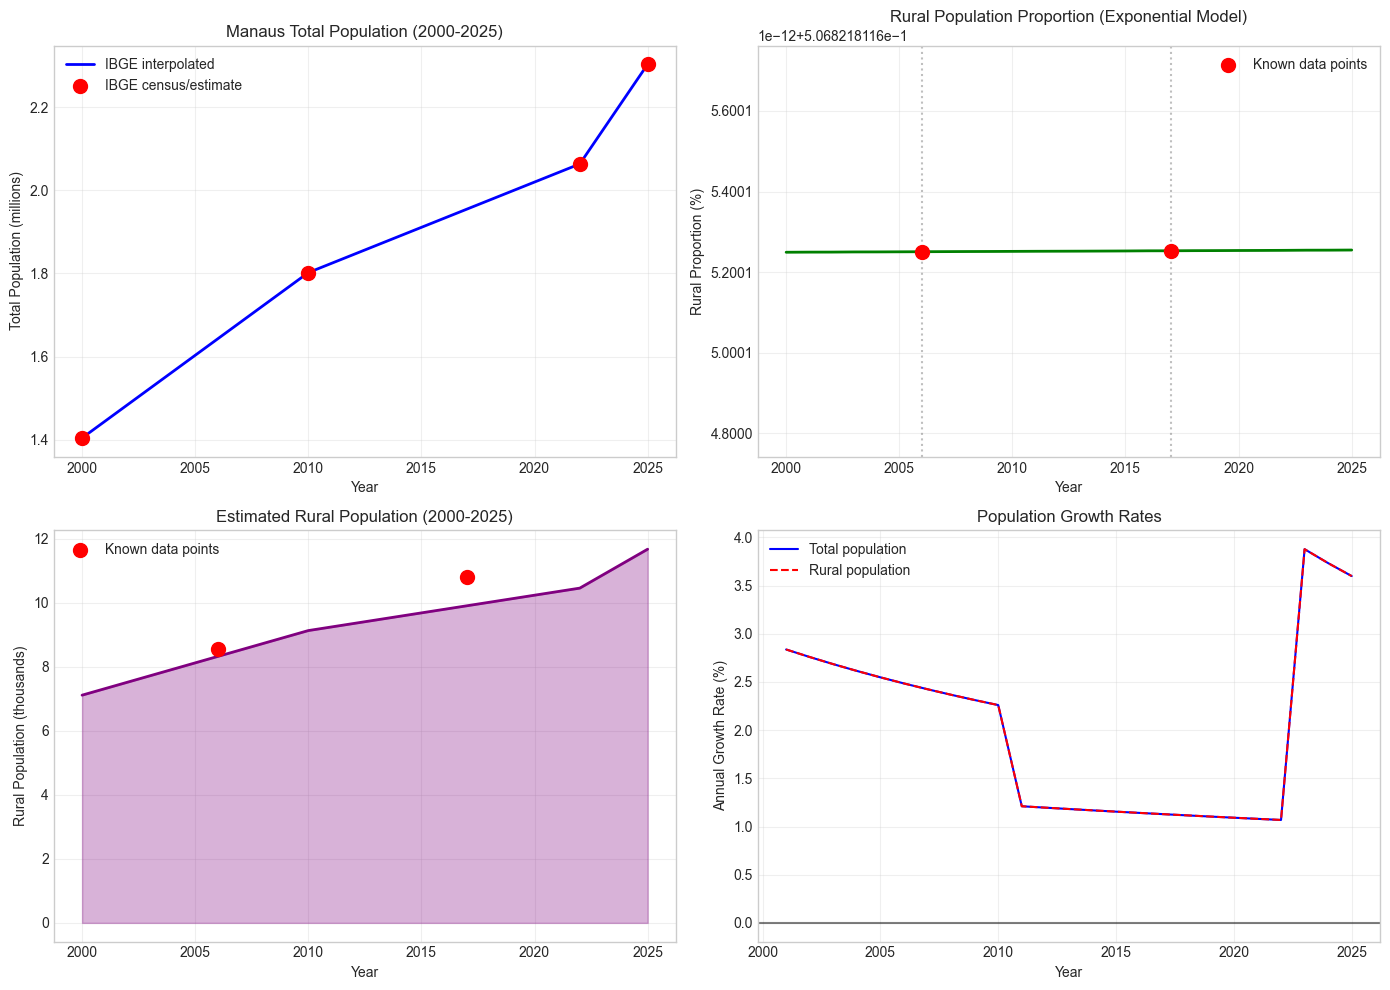

In [47]:
# ============================================
# COMPLETE TIME SERIES VISUALIZATION (2000-2025)
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Total population (IBGE interpolated)
axes[0,0].plot(annual_rural_df['year'], annual_rural_df['total_population'] / 1e6, 
               'b-', linewidth=2, label='IBGE interpolated')
axes[0,0].scatter([2000, 2010, 2022, 2025], 
                  [pop_manaus_2000/1e6, pop_manaus_2010/1e6, pop_manaus_2022/1e6, pop_manaus_2025/1e6],
                  color='red', s=100, zorder=5, label='IBGE census/estimate')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Total Population (millions)')
axes[0,0].set_title('Manaus Total Population (2000-2025)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Rural proportion over time
axes[0,1].plot(annual_rural_df['year'], annual_rural_df['rural_proportion'] * 100, 
               'g-', linewidth=2)
axes[0,1].scatter([2006, 2017], [prop_rural_2006*100, prop_rural_2017*100], 
                  color='red', s=100, zorder=5, label='Known data points')
axes[0,1].axvline(x=2006, color='gray', linestyle=':', alpha=0.5)
axes[0,1].axvline(x=2017, color='gray', linestyle=':', alpha=0.5)
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Rural Proportion (%)')
axes[0,1].set_title('Rural Population Proportion (Exponential Model)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Rural population
axes[1,0].plot(annual_rural_df['year'], annual_rural_df['rural_population'] / 1000, 
               'purple', linewidth=2)
axes[1,0].scatter([2006, 2017], [rural_pop_2006/1000, rural_pop_2017/1000], 
                  color='red', s=100, zorder=5, label='Known data points')
axes[1,0].fill_between(annual_rural_df['year'], 0, annual_rural_df['rural_population'] / 1000, 
                       alpha=0.3, color='purple')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Rural Population (thousands)')
axes[1,0].set_title('Estimated Rural Population (2000-2025)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Annual growth rates
annual_rural_df['total_pop_growth'] = annual_rural_df['total_population'].pct_change() * 100
annual_rural_df['rural_pop_growth'] = annual_rural_df['rural_population'].pct_change() * 100

axes[1,1].plot(annual_rural_df['year'][1:], annual_rural_df['total_pop_growth'][1:], 
               'b-', label='Total population', linewidth=1.5)
axes[1,1].plot(annual_rural_df['year'][1:], annual_rural_df['rural_pop_growth'][1:], 
               'r--', label='Rural population', linewidth=1.5)
axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Annual Growth Rate (%)')
axes[1,1].set_title('Population Growth Rates')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

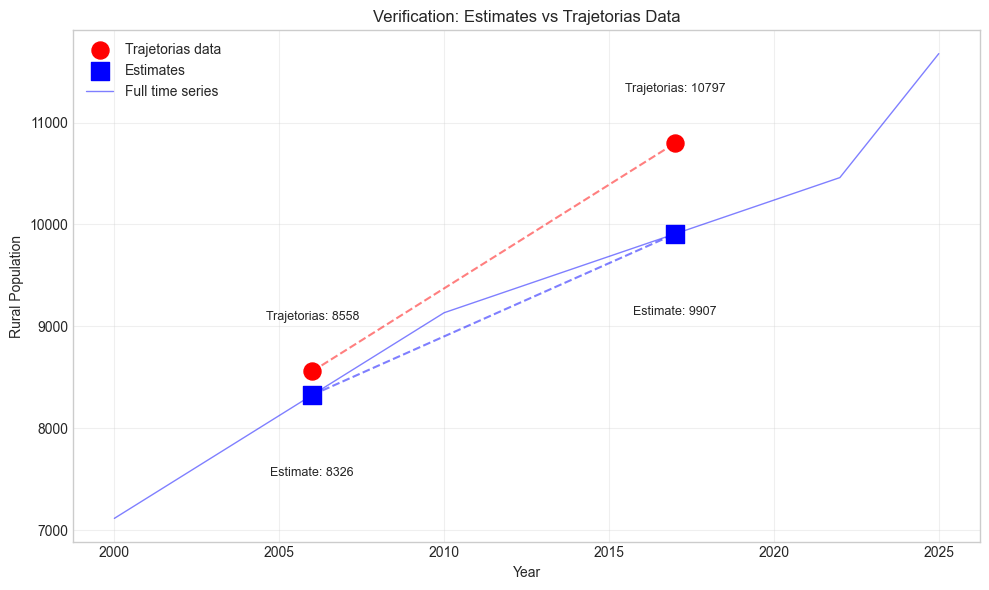


Verification:
  2006 - Difference: 232 (2.71%)
  2017 - Difference: 890 (8.24%)


In [48]:
# ============================================
# VERIFICATION: COMPARE WITH TRAJETORIAS DATA
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))

# Trajetorias data points
trajetorias_years = [2006, 2017]
trajetorias_rural_pop = [rural_pop_2006, rural_pop_2017]

# Estimates
estimates_2006 = annual_rural_df[annual_rural_df['year'] == 2006]['rural_population'].values[0]
estimates_2017 = annual_rural_df[annual_rural_df['year'] == 2017]['rural_population'].values[0]

# Plot
ax.scatter(trajetorias_years, trajetorias_rural_pop, color='red', s=150, 
           marker='o', label='Trajetorias data', zorder=5)
ax.scatter([2006, 2017], [estimates_2006, estimates_2017], color='blue', s=150,
           marker='s', label='Estimates', zorder=5)

# Connect with lines
ax.plot([2006, 2017], [rural_pop_2006, rural_pop_2017], 'r--', alpha=0.5)
ax.plot([2006, 2017], [estimates_2006, estimates_2017], 'b--', alpha=0.5)

# Full time series
ax.plot(annual_rural_df['year'], annual_rural_df['rural_population'], 
        'b-', linewidth=1, alpha=0.5, label='Full time series')

ax.set_xlabel('Year')
ax.set_ylabel('Rural Population')
ax.set_title('Verification: Estimates vs Trajetorias Data')
ax.legend()
ax.grid(True, alpha=0.3)

# Add text showing differences
ax.text(2006, rural_pop_2006 + 500, f'Trajetorias: {rural_pop_2006:.0f}', 
        ha='center', fontsize=9)
ax.text(2006, estimates_2006 - 800, f'Estimate: {estimates_2006:.0f}', 
        ha='center', fontsize=9)
ax.text(2017, rural_pop_2017 + 500, f'Trajetorias: {rural_pop_2017:.0f}', 
        ha='center', fontsize=9)
ax.text(2017, estimates_2017 - 800, f'Estimate: {estimates_2017:.0f}', 
        ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nVerification:")
print(f"  2006 - Difference: {abs(estimates_2006 - rural_pop_2006):.0f} ({abs(estimates_2006 - rural_pop_2006)/rural_pop_2006*100:.2f}%)")
print(f"  2017 - Difference: {abs(estimates_2017 - rural_pop_2017):.0f} ({abs(estimates_2017 - rural_pop_2017)/rural_pop_2017*100:.2f}%)")

-------------------------

### Now, we will substitute the estimated rural population proportion used the test incidences calculated previously

In [51]:
# Population from incidence formula: Pop = (Cases × 100000) / (Inc × 5 years)
pop_rural_04_08 = rural_cases_04_08 * 100000 / (test_rural_inc_2004_2008 * 5)
pop_total_04_08 = total_cases_04_08 * 100000 / (test_total_inc_2004_2008 * 5)
pop_ratio_04_08 = pop_rural_04_08 / pop_total_04_08

pop_rural_15_19 = rural_cases_15_19 * 100000 / (test_rural_inc_2015_2019 * 5)
pop_total_15_19 = total_cases_15_19 * 100000 / (test_total_inc_2015_2019 * 5)
pop_ratio_15_19 = pop_rural_15_19 / pop_total_15_19

print(f"\nPopulation Ratios (Rural/Total) from Incidence:")
print(f"  2004-2008: {pop_ratio_04_08*100:.2f}% (rural pop: {pop_rural_04_08:,.0f})")
print(f"  2015-2019: {pop_ratio_15_19*100:.2f}% (rural pop: {pop_rural_15_19:,.0f})")


Population Ratios (Rural/Total) from Incidence:
  2004-2008: 0.51% (rural pop: 8,558)
  2015-2019: 0.51% (rural pop: 10,797)


In [52]:
r_test_inc = (test_rural_inc_2015_2019/test_rural_inc_2004_2008)**(1/11) -1
r_test_inc

-0.11517005707359518

In [53]:
test_rural_inc_20 = test_rural_inc_2015_2019*(1+r_test_inc)**(2020-2017)
test_rural_inc_21 = test_rural_inc_2015_2019*(1+r_test_inc)**(2021-2017)
test_rural_inc_22 = test_rural_inc_2015_2019*(1+r_test_inc)**(2022-2017)
test_rural_inc_23 = test_rural_inc_2015_2019*(1+r_test_inc)**(2023-2017)

print(f'The rural incidence in the years of 2020 to 2023 are estimated to be, respectively: \n{test_rural_inc_20}, {test_rural_inc_21}, {test_rural_inc_22}, {test_rural_inc_23}')

The rural incidence in the years of 2020 to 2023 are estimated to be, respectively: 
33183.183836496304, 29361.474660163425, 25979.911947787485, 22987.80400599382


In [54]:
pop_data_clean = pop_data.copy()
pop_data_clean.drop(columns=['index', 'ADJUSTED_RURAL_POP'])
pop_data_clean = pop_data_clean[['date', 'ADJUSTED_POPULATION']]
pop_data_clean

,date,ADJUSTED_POPULATION
0,2017-01-01,1.954657e+06
1,2017-01-02,1.954717e+06
2,2017-01-03,1.954776e+06
3,2017-01-04,1.954836e+06
4,2017-01-05,1.954896e+06
...,...,...
2551,2023-12-27,2.222621e+06
2552,2023-12-28,2.222840e+06
2553,2023-12-29,2.223059e+06
2554,2023-12-30,2.223279e+06


In [55]:
# ============================================
# CALCULATE DAILY RURAL POPULATION
# ============================================

# Create a function to get rural proportion for any date
def get_rural_proportion(date, prop_2006, prop_2017, year_2006=2006, year_2017=2017):
    """
    Calculate rural proportion for a given date using exponential interpolation/extrapolation
    """
    # Convert date to decimal year
    year = date.year
    day_of_year = date.timetuple().tm_yday
    days_in_year = 366 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 365
    year_frac = year + (day_of_year - 0.5) / days_in_year
    
    if year_frac <= year_2017:
        # Interpolate between 2006 and 2017
        t = (year_frac - year_2006) / (year_2017 - year_2006)
        # Linear interpolation on log scale for exponential trend
        prop = prop_2006 * (prop_2017 / prop_2006) ** t
    else:
        # Extrapolate beyond 2017
        r_p = (prop_2017 / prop_2006) ** (1/(year_2017 - year_2006)) - 1
        prop = prop_2017 * (1 + r_p) ** (year_frac - year_2017)
    
    return prop

# Calculate rural proportion for each day in pop_data
pop_data_clean = pop_data[['date', 'ADJUSTED_POPULATION']].copy()
pop_data_clean['rural_proportion'] = pop_data_clean['date'].apply(
    lambda d: get_rural_proportion(d, prop_rural_2006, prop_rural_2017)
)
pop_data_clean['rural_population'] = pop_data_clean['ADJUSTED_POPULATION'] * pop_data_clean['rural_proportion']

print(f"\nRural population statistics (2017-2023):")
print(f"  Min: {pop_data_clean['rural_population'].min():,.0f}")
print(f"  Max: {pop_data_clean['rural_population'].max():,.0f}")
print(f"  Mean: {pop_data_clean['rural_population'].mean():,.0f}")

pop_data_clean


Rural population statistics (2017-2023):
  Min: 9,907
  Max: 11,269
  Mean: 10,377


,date,ADJUSTED_POPULATION,rural_proportion,rural_population
0,2017-01-01,1.954657e+06,0.005068,9906.628018
1,2017-01-02,1.954717e+06,0.005068,9906.930820
2,2017-01-03,1.954776e+06,0.005068,9907.233621
3,2017-01-04,1.954836e+06,0.005068,9907.536423
4,2017-01-05,1.954896e+06,0.005068,9907.839225
...,...,...,...,...
2551,2023-12-27,2.222621e+06,0.005068,11264.727601
2552,2023-12-28,2.222840e+06,0.005068,11265.838637
2553,2023-12-29,2.223059e+06,0.005068,11266.949674
2554,2023-12-30,2.223279e+06,0.005068,11268.060711


In [56]:
# ============================================
# CALCULATE DAILY INCIDENCE RATES
# ============================================

# We have:
# rural_inc_15_19 = 60,433.7 cases per 100,000 person-years for 2015-2019
# This applies to 2015, 2016, 2017, 2018, 2019

# For 2020-2023, we already extrapolated:
# rural_inc_20, rural_inc_21, rural_inc_22, rural_inc_23

def get_annual_incidence(date, inc_2017, inc_2020, inc_2021, inc_2022, inc_2023):
    """
    Get annual incidence rate (per 100,000 person-years) for a given date
    """
    year = date.year
    
    if year <= 2019:
        return inc_2017  # Use 2015-2019 average for 2017-2019
    elif year == 2020:
        return inc_2020
    elif year == 2021:
        return inc_2021
    elif year == 2022:
        return inc_2022
    elif year == 2023:
        return inc_2023
    else:
        # For any other year, continue extrapolation
        r = (test_rural_inc_2015_2019 / test_rural_inc_2004_2008) ** (1/11) - 1
        return test_rural_inc_2015_2019 * (1 + r) ** (year - 2017)

# Add incidence to dataframe
pop_data_clean['annual_incidence_per_100k'] = pop_data_clean['date'].apply(
    lambda d: get_annual_incidence(d, test_rural_inc_2015_2019, test_rural_inc_20, test_rural_inc_21, test_rural_inc_22, test_rural_inc_23)
)

# Convert to daily rate (per person per day)
# Daily rate = (annual_incidence_per_100k / 100,000) / 365.25
pop_data_clean['daily_incidence_rate'] = (pop_data_clean['annual_incidence_per_100k'] / 100000) / 365.25

print(f"\nIncidence rates:")
print(f"  2017-2019: {test_rural_inc_2015_2019:.2f} per 100,000 person-years")
print(f"  2020: {test_rural_inc_20:.2f} per 100,000 person-years")
print(f"  2021: {test_rural_inc_21:.2f} per 100,000 person-years")
print(f"  2022: {test_rural_inc_22:.2f} per 100,000 person-years")
print(f"  2023: {test_rural_inc_23:.2f} per 100,000 person-years")

pop_data_clean


Incidence rates:
  2017-2019: 47900.34 per 100,000 person-years
  2020: 33183.18 per 100,000 person-years
  2021: 29361.47 per 100,000 person-years
  2022: 25979.91 per 100,000 person-years
  2023: 22987.80 per 100,000 person-years


,date,ADJUSTED_POPULATION,rural_proportion,rural_population,annual_incidence_per_100k,daily_incidence_rate
0,2017-01-01,1.954657e+06,0.005068,9906.628018,47900.342688,0.001311
1,2017-01-02,1.954717e+06,0.005068,9906.930820,47900.342688,0.001311
2,2017-01-03,1.954776e+06,0.005068,9907.233621,47900.342688,0.001311
3,2017-01-04,1.954836e+06,0.005068,9907.536423,47900.342688,0.001311
4,2017-01-05,1.954896e+06,0.005068,9907.839225,47900.342688,0.001311
...,...,...,...,...,...,...
2551,2023-12-27,2.222621e+06,0.005068,11264.727601,22987.804006,0.000629
2552,2023-12-28,2.222840e+06,0.005068,11265.838637,22987.804006,0.000629
2553,2023-12-29,2.223059e+06,0.005068,11266.949674,22987.804006,0.000629
2554,2023-12-30,2.223279e+06,0.005068,11268.060711,22987.804006,0.000629


In [57]:
# ============================================
# CALCULATE EXPECTED DAILY CASES
# ============================================

# Expected cases = daily_incidence_rate * rural_population
pop_data_clean['expected_daily_cases'] = pop_data_clean['daily_incidence_rate'] * pop_data_clean['rural_population']

print(f"\nExpected daily cases statistics (2017-2023):")
print(f"  Min: {pop_data_clean['expected_daily_cases'].min():.2f}")
print(f"  Max: {pop_data_clean['expected_daily_cases'].max():.2f}")
print(f"  Mean: {pop_data_clean['expected_daily_cases'].mean():.2f}")
print(f"  Total (sum): {pop_data_clean['expected_daily_cases'].sum():.0f}")

pop_data_clean


Expected daily cases statistics (2017-2023):
  Min: 6.84
  Max: 13.43
  Mean: 10.27
  Total (sum): 26250


,date,ADJUSTED_POPULATION,rural_proportion,rural_population,annual_incidence_per_100k,daily_incidence_rate,expected_daily_cases
0,2017-01-01,1.954657e+06,0.005068,9906.628018,47900.342688,0.001311,12.991947
1,2017-01-02,1.954717e+06,0.005068,9906.930820,47900.342688,0.001311,12.992344
2,2017-01-03,1.954776e+06,0.005068,9907.233621,47900.342688,0.001311,12.992742
3,2017-01-04,1.954836e+06,0.005068,9907.536423,47900.342688,0.001311,12.993139
4,2017-01-05,1.954896e+06,0.005068,9907.839225,47900.342688,0.001311,12.993536
...,...,...,...,...,...,...,...
2551,2023-12-27,2.222621e+06,0.005068,11264.727601,22987.804006,0.000629,7.089702
2552,2023-12-28,2.222840e+06,0.005068,11265.838637,22987.804006,0.000629,7.090401
2553,2023-12-29,2.223059e+06,0.005068,11266.949674,22987.804006,0.000629,7.091100
2554,2023-12-30,2.223279e+06,0.005068,11268.060711,22987.804006,0.000629,7.091799


In [58]:
# ============================================
# AGGREGATE RESULTS BY YEAR
# ============================================

# Add year column
pop_data_clean['year'] = pop_data_clean['date'].dt.year

# Aggregate by year
yearly_summary = pop_data_clean.groupby('year').agg({
    'rural_population': 'mean',
    'annual_incidence_per_100k': 'first',
    'expected_daily_cases': 'sum'
}).round(2)

yearly_summary['expected_yearly_cases'] = yearly_summary['expected_daily_cases']
yearly_summary['expected_yearly_cases_per_100k'] = (yearly_summary['expected_yearly_cases'] / yearly_summary['rural_population']) * 100000

print("\n=== YEARLY SUMMARY ===\n")
print(yearly_summary[['rural_population', 'annual_incidence_per_100k', 'expected_yearly_cases', 'expected_yearly_cases_per_100k']])

# Total for 2017-2023
total_cases_2017_2023 = pop_data_clean['expected_daily_cases'].sum()
total_rural_pop_mean = pop_data_clean['rural_population'].mean()

print(f"\n=== TOTAL 2017-2023 ===\n")
print(f"Total expected rural cases: {total_cases_2017_2023:.0f}")
print(f"Mean rural population: {total_rural_pop_mean:.0f}")
print(f"Overall incidence rate: {(total_cases_2017_2023 / total_rural_pop_mean) * 100000:.2f} per 100,000 person-years")


=== YEARLY SUMMARY ===

      rural_population  annual_incidence_per_100k  expected_yearly_cases  \
year                                                                       
2017           9961.74                   47900.34                4768.44   
2018          10072.26                   47900.34                4821.34   
2019          10182.78                   47900.34                4874.25   
2020          10293.29                   33183.18                3422.66   
2021          10403.81                   29361.47                3052.62   
2022          10661.43                   25979.91                2767.94   
2023          11066.96                   22987.80                2542.31   

      expected_yearly_cases_per_100k  
year                                  
2017                    47867.541213  
2018                    47867.509377  
2019                    47867.576438  
2020                    33251.370553  
2021                    29341.366288  
2022             

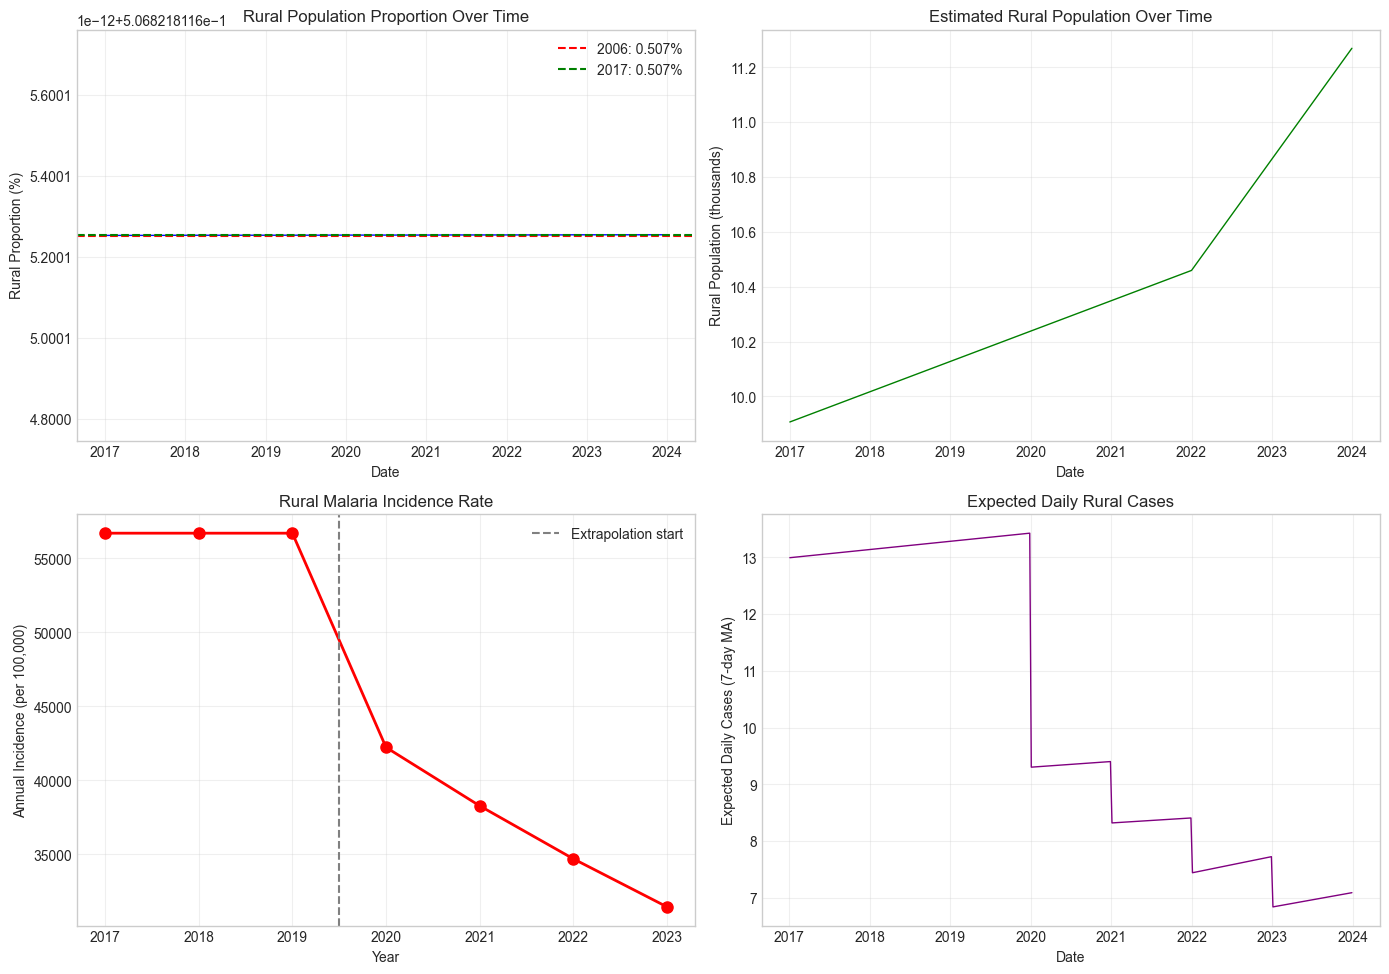

In [59]:
# ============================================
# VISUALIZATION
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Rural proportion over time
axes[0,0].plot(pop_data_clean['date'], pop_data_clean['rural_proportion'] * 100, 'b-', linewidth=1)
axes[0,0].axhline(y=prop_rural_2006*100, color='r', linestyle='--', label=f'2006: {prop_rural_2006*100:.3f}%')
axes[0,0].axhline(y=prop_rural_2017*100, color='g', linestyle='--', label=f'2017: {prop_rural_2017*100:.3f}%')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Rural Proportion (%)')
axes[0,0].set_title('Rural Population Proportion Over Time')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Rural population
axes[0,1].plot(pop_data_clean['date'], pop_data_clean['rural_population'] / 1000, 'g-', linewidth=1)
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Rural Population (thousands)')
axes[0,1].set_title('Estimated Rural Population Over Time')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Annual incidence rate
years_for_plot = [2017, 2018, 2019, 2020, 2021, 2022, 2023]
incidence_for_plot = [rural_inc_15_19, rural_inc_15_19, rural_inc_15_19, 
                      rural_inc_20, rural_inc_21, rural_inc_22, rural_inc_23]
axes[1,0].plot(years_for_plot, incidence_for_plot, 'r-o', linewidth=2, markersize=8)
axes[1,0].axvline(x=2019.5, color='gray', linestyle='--', label='Extrapolation start')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Annual Incidence (per 100,000)')
axes[1,0].set_title('Rural Malaria Incidence Rate')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Expected daily cases (7-day moving average)
pop_data_clean['cases_7day_ma'] = pop_data_clean['expected_daily_cases'].rolling(window=7, center=True).mean()
axes[1,1].plot(pop_data_clean['date'], pop_data_clean['cases_7day_ma'], 'purple', linewidth=1)
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Expected Daily Cases (7-day MA)')
axes[1,1].set_title('Expected Daily Rural Cases')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()